In [2]:
!pip install lime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import lime.lime_tabular

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d64972bc8dc9fb051303f10f785216747f5336921ddeabc6feba7414f95b8d59
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [3]:
df = pd.read_csv("/content/heart_statlog_cleveland_hungary_final (1).csv")
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [4]:
df.dropna(inplace=True)
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [5]:
df.duplicated().sum()

np.int64(272)

In [6]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")

# View them
print(duplicate_rows)

Number of duplicate rows: 272
      age  sex  chest pain type  resting bp s  cholesterol  \
163    49    0                2           110          208   
604    58    1                3           150          219   
887    63    1                1           145          233   
888    67    1                4           160          286   
889    67    1                4           120          229   
...   ...  ...              ...           ...          ...   
1156   42    1                3           130          180   
1157   61    1                4           140          207   
1158   66    1                4           160          228   
1159   46    1                4           140          311   
1160   71    0                4           112          149   

      fasting blood sugar  resting ecg  max heart rate  exercise angina  \
163                     0            0             160                0   
604                     0            1             118                1   


In [7]:
df.drop_duplicates(inplace=True)
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


Class distribution (counts):
 target
1    508
0    410
Name: count, dtype: int64

Class distribution (percentages):
 target
1    55.34
0    44.66
Name: proportion, dtype: float64


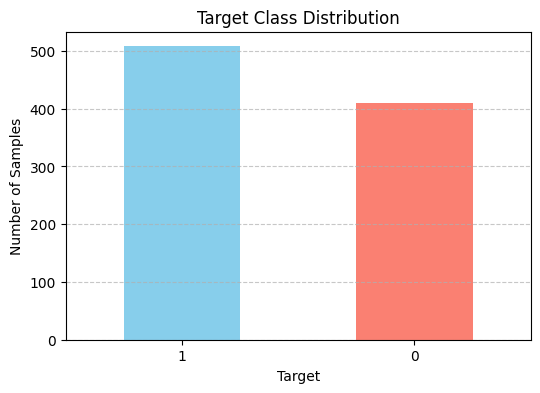

In [8]:
# Assuming df_cleaned is your cleaned DataFrame
class_counts = df['target'].value_counts()
class_percentages = df['target'].value_counts(normalize=True) * 100

# Print numerical summary
print("Class distribution (counts):\n", class_counts)
print("\nClass distribution (percentages):\n", class_percentages.round(2))

# Plot
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Target Class Distribution')
plt.xlabel('Target')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
X = df.drop('target', axis=1)
y = df['target']
adasyn = ADASYN(random_state=42, sampling_strategy='minority')
X_resampled, y_resampled = adasyn.fit_resample(X, y)

In [10]:
# Combine X and y into a new DataFrame
df_adasyn = pd.DataFrame(X_resampled, columns=X.columns)
df_adasyn['target'] = y_resampled

# Optional: Shuffle the data
df_adasyn = df_adasyn.sample(frac=1, random_state=42).reset_index(drop=True)

# Preview
print(df_adasyn.head())
print(df_adasyn['target'].value_counts())

   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   74    1                3           140          237                    1   
1   73    1                3           138            0                    0   
2   43    1                4           150          247                    0   
3   65    1                4           170          263                    1   
4   48    0                4           150          227                    0   

   resting ecg  max heart rate  exercise angina   oldpeak  ST slope  target  
0            0              94                0  0.000000         2       1  
1            0             116                0  0.196807         1       0  
2            0             130                1  2.000000         2       1  
3            0             112                1  2.000000         2       1  
4            0             130                1  1.000000         2       0  
target
1    508
0    439
Name: count, dtype: int64


In [11]:
df = df_adasyn

# **EDA**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  947 non-null    int64  
 1   sex                  947 non-null    int64  
 2   chest pain type      947 non-null    int64  
 3   resting bp s         947 non-null    int64  
 4   cholesterol          947 non-null    int64  
 5   fasting blood sugar  947 non-null    int64  
 6   resting ecg          947 non-null    int64  
 7   max heart rate       947 non-null    int64  
 8   exercise angina      947 non-null    int64  
 9   oldpeak              947 non-null    float64
 10  ST slope             947 non-null    int64  
 11  target               947 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 88.9 KB


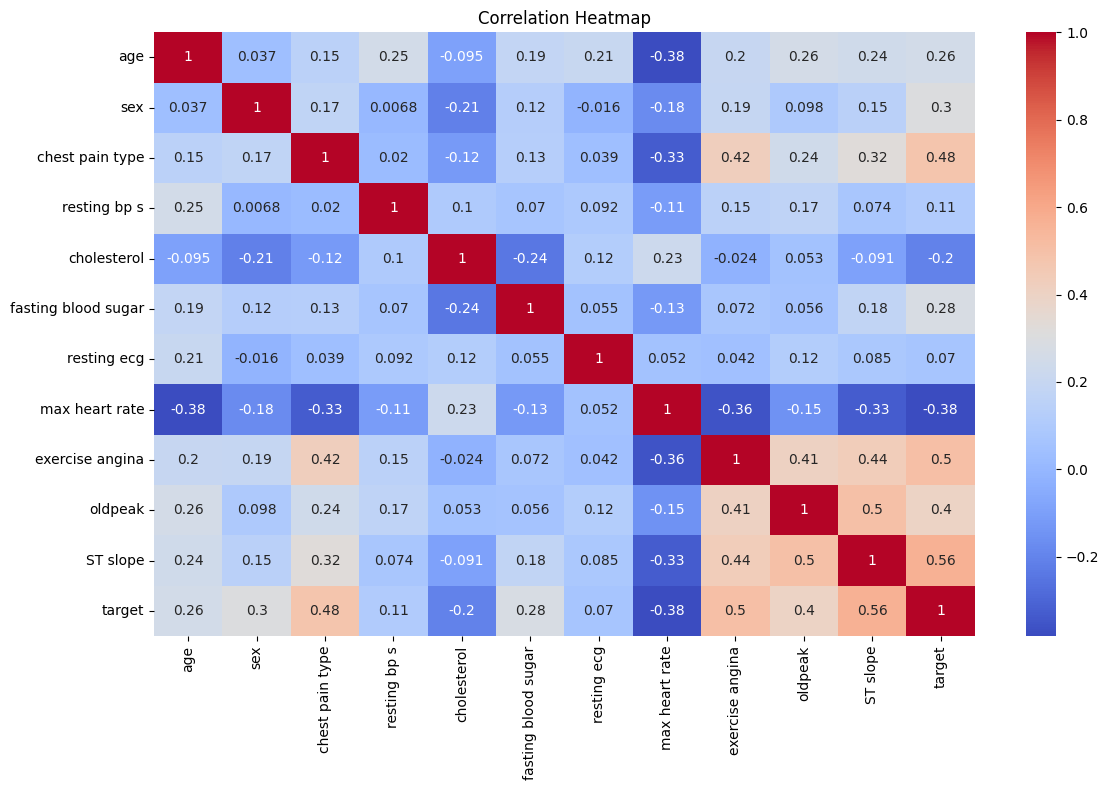

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [14]:
df['bp_cp_interaction'] = df['resting bp s'] * df['chest pain type']
df['angina_cp_interaction'] = df['exercise angina'] * df['chest pain type']
df['angina_hr_product'] = df['exercise angina'] * df['max heart rate']

In [15]:
df.drop(columns=['max heart rate', 'resting ecg', 'cholesterol', 'resting bp s'], inplace=True)

In [16]:
df.rename(columns={
    'chest pain type': 'cp',
    'resting bp s': 'trestbps',
    'cholesterol': 'chol',
    'fasting blood sugar': 'fbs',
    'resting ecg': 'restecg',
    'max heart rate': 'thalach',
    'exercise angina': 'exang',
    'ST slope': 'slope'
}, inplace=True)


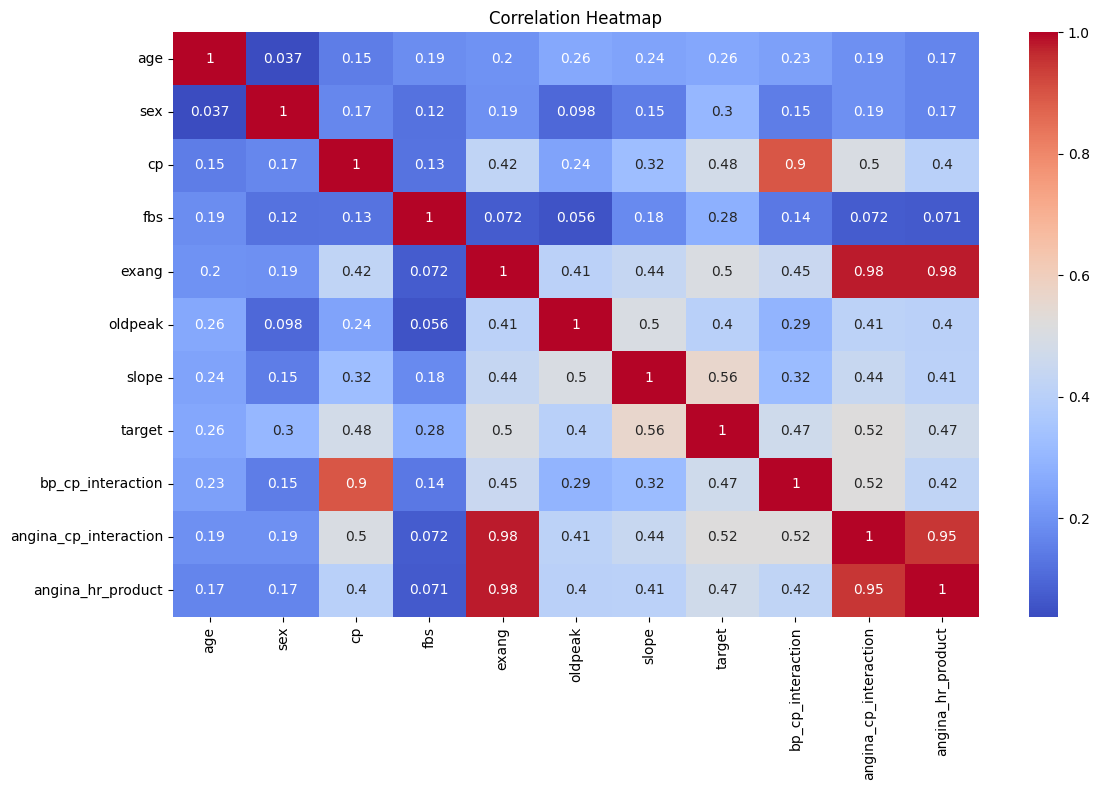

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    947 non-null    int64  
 1   sex                    947 non-null    int64  
 2   cp                     947 non-null    int64  
 3   fbs                    947 non-null    int64  
 4   exang                  947 non-null    int64  
 5   oldpeak                947 non-null    float64
 6   slope                  947 non-null    int64  
 7   target                 947 non-null    int64  
 8   bp_cp_interaction      947 non-null    int64  
 9   angina_cp_interaction  947 non-null    int64  
 10  angina_hr_product      947 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 81.5 KB


<ipython-input-19-27ff83694f41>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


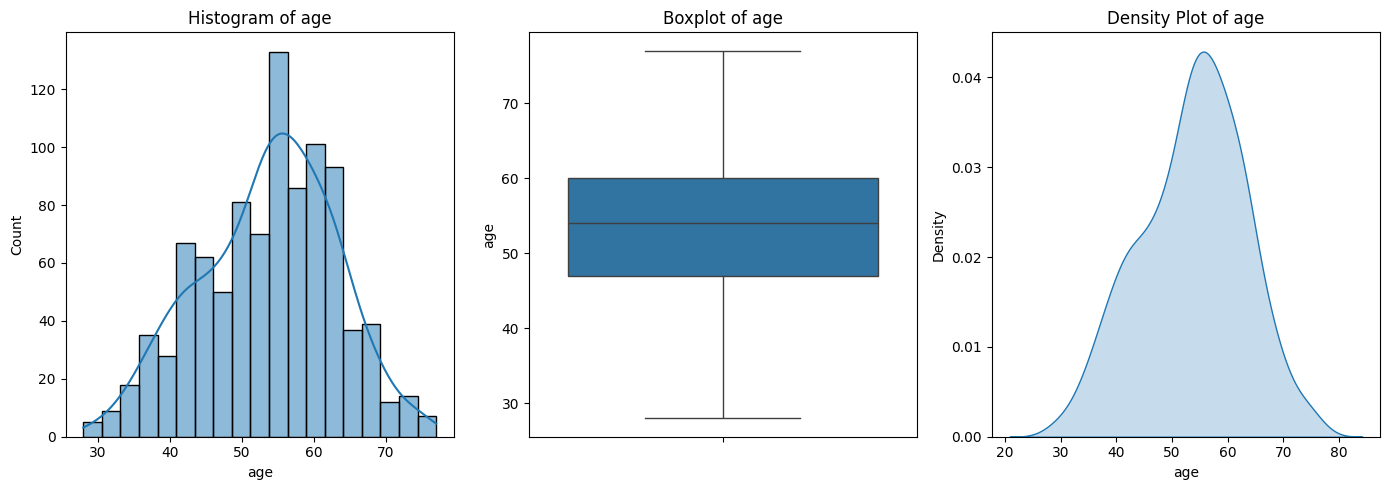

<ipython-input-19-27ff83694f41>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


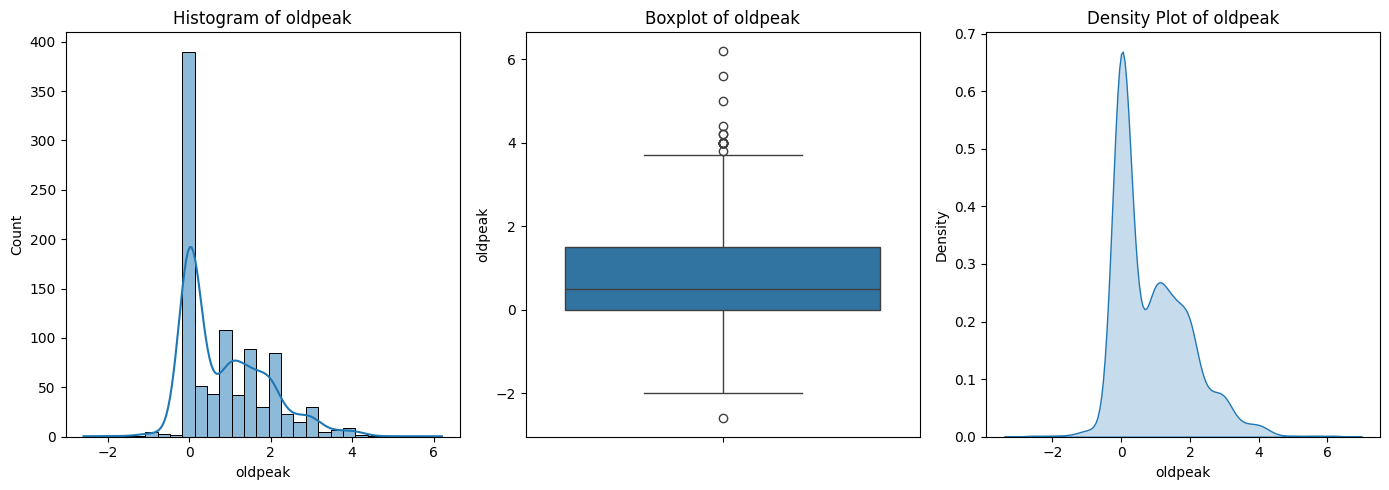

<ipython-input-19-27ff83694f41>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


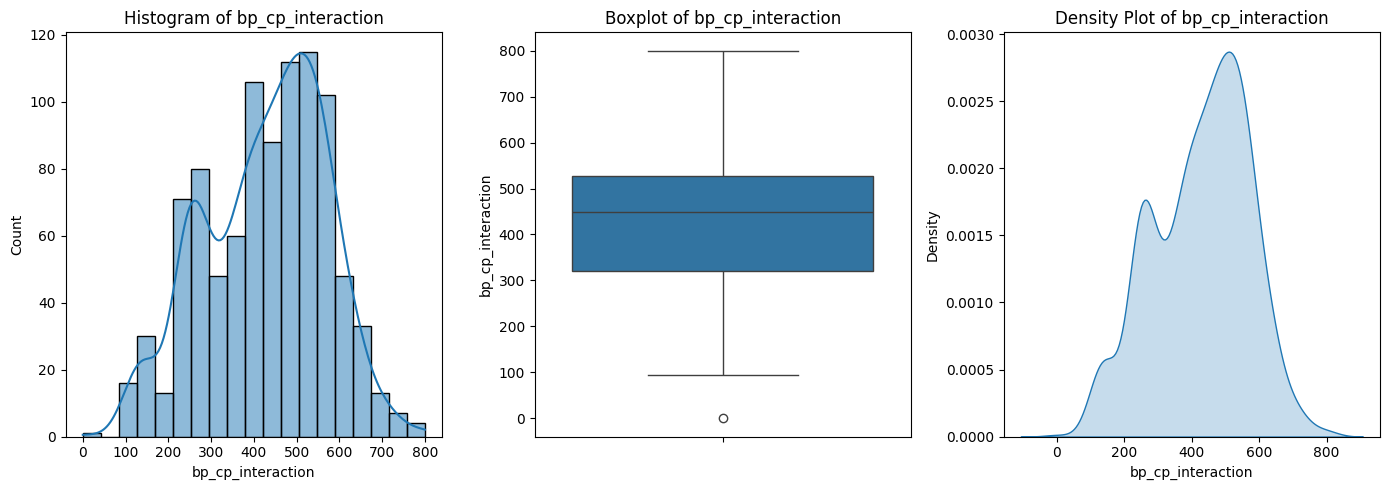

<ipython-input-19-27ff83694f41>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


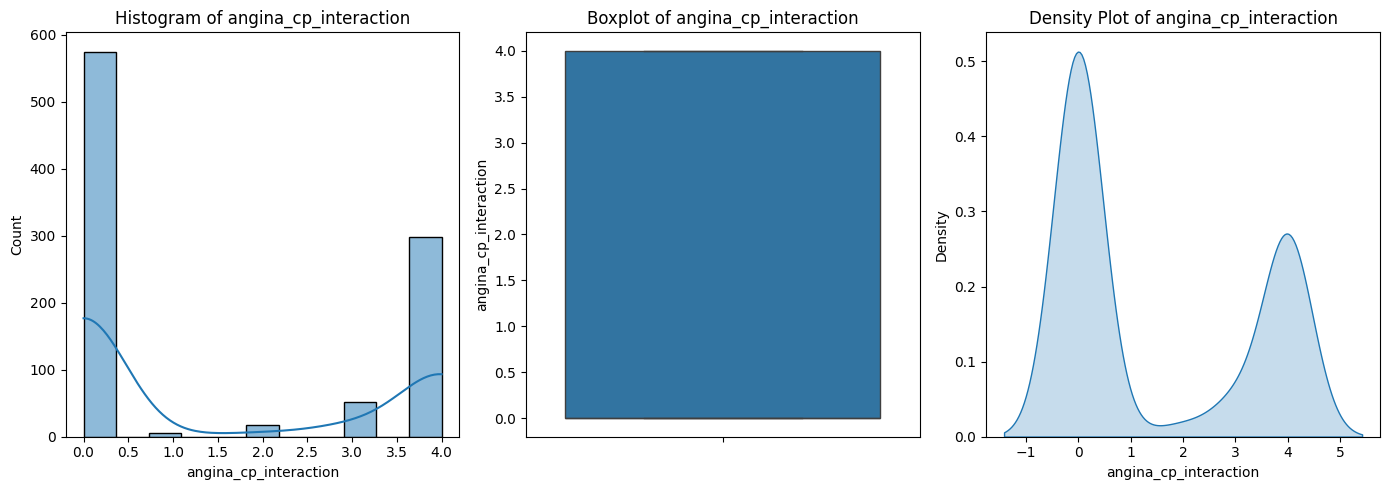

<ipython-input-19-27ff83694f41>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


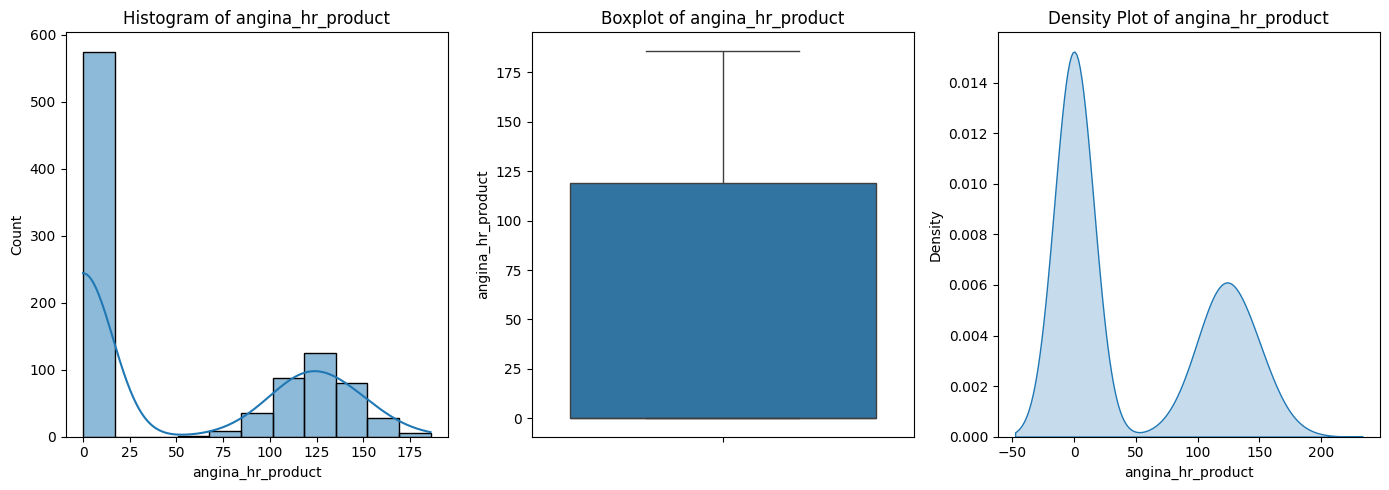

In [19]:
numeric_cols = ['age', 'oldpeak', 'bp_cp_interaction', 'angina_cp_interaction', 'angina_hr_product']

# Histograms and Boxplots for Numerical Features
for col in numeric_cols:
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

    plt.subplot(1, 3, 3)
    sns.kdeplot(df[col], shade=True)
    plt.title(f'Density Plot of {col}')

    plt.tight_layout()
    plt.show()

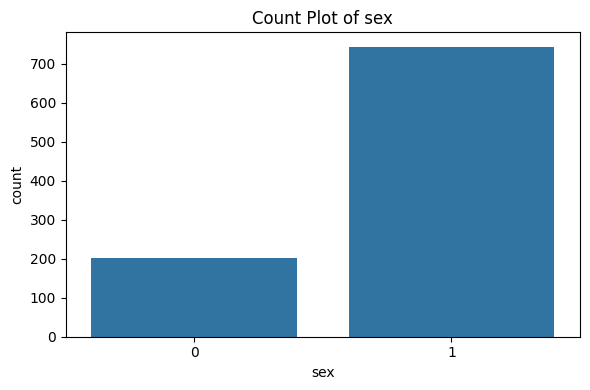

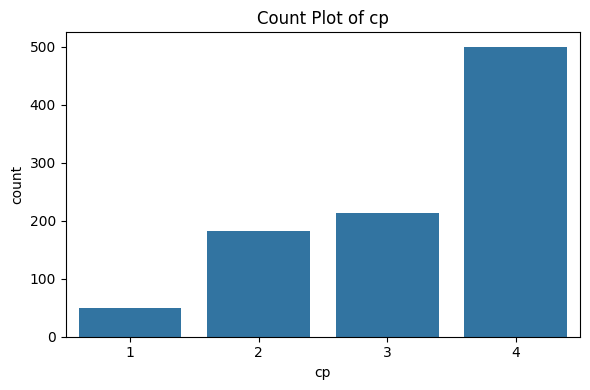

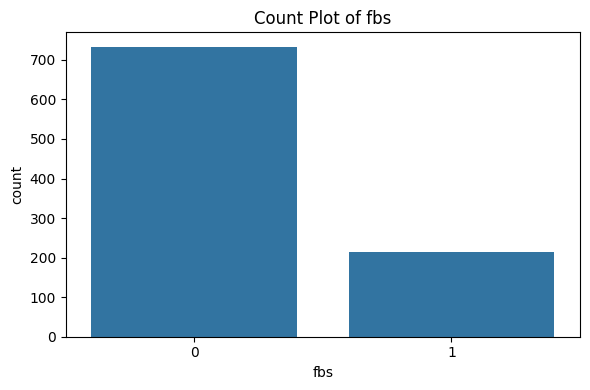

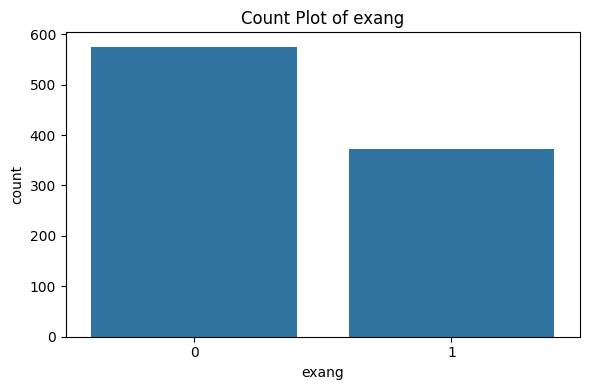

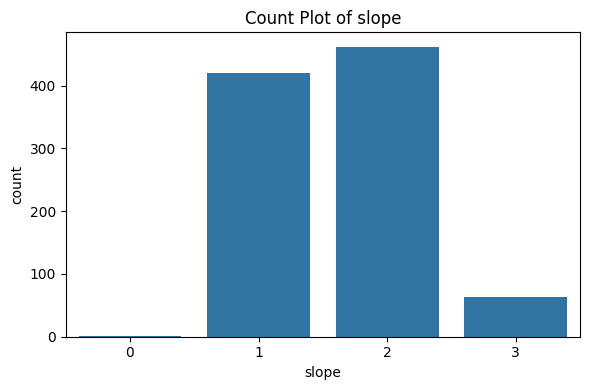

In [20]:
categorical_cols = ['sex', 'cp', 'fbs', 'exang', 'slope']

# Categorical Features
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.tight_layout()
    plt.show()

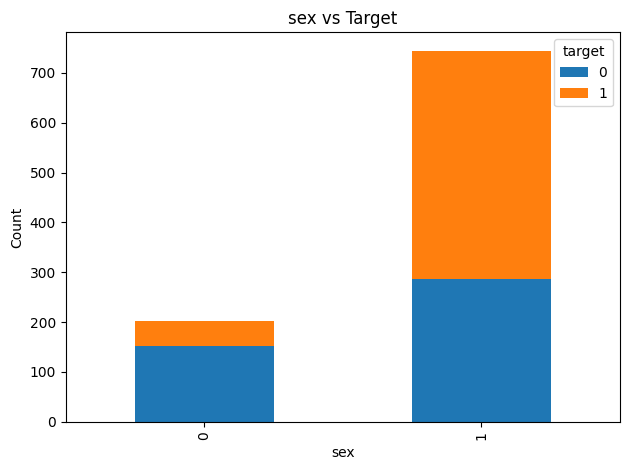

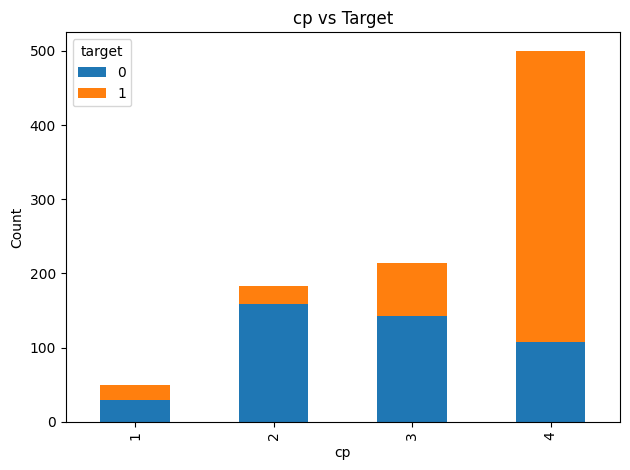

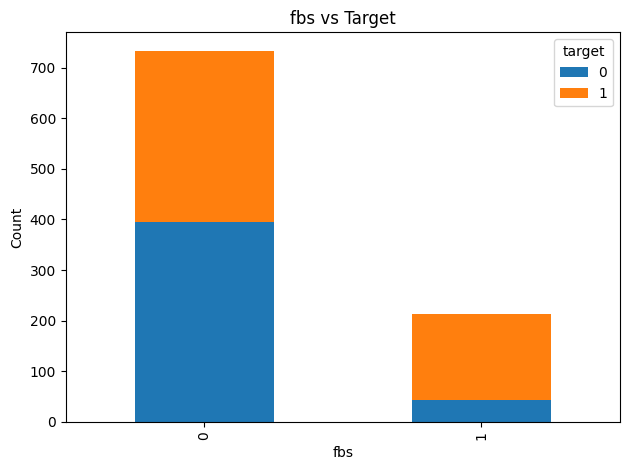

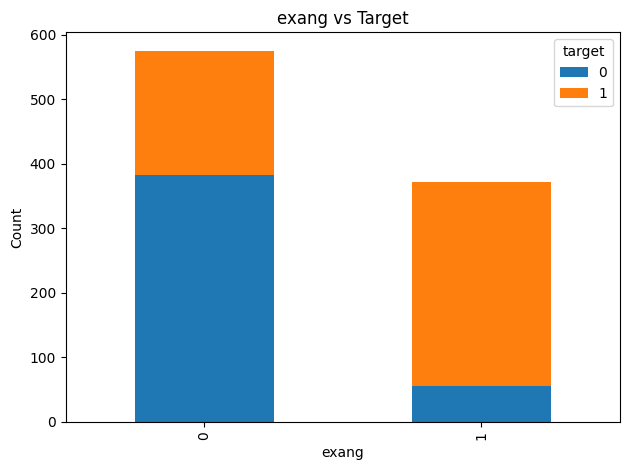

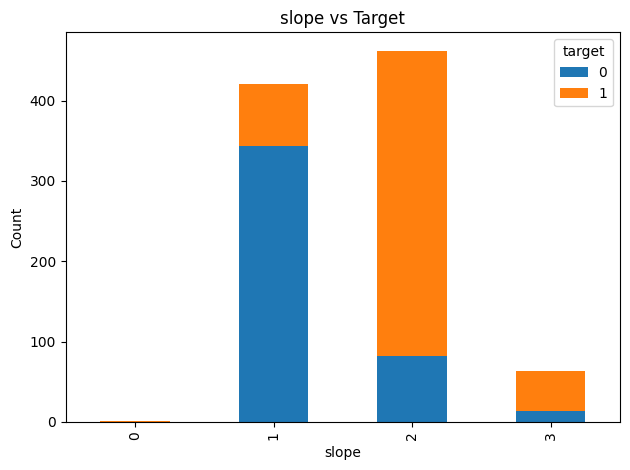

In [21]:
#Categorical vs Target
for col in categorical_cols:
    pd.crosstab(df[col], df['target']).plot(kind='bar', stacked=True)
    plt.title(f'{col} vs Target')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

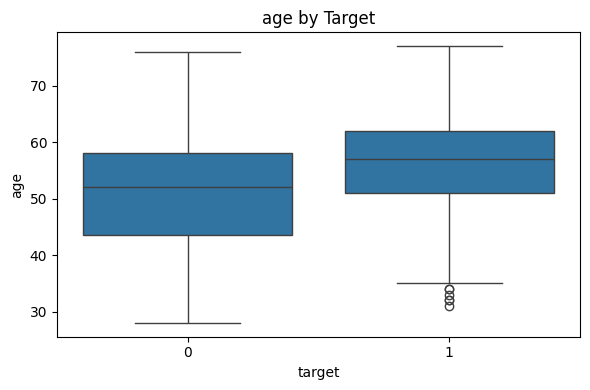

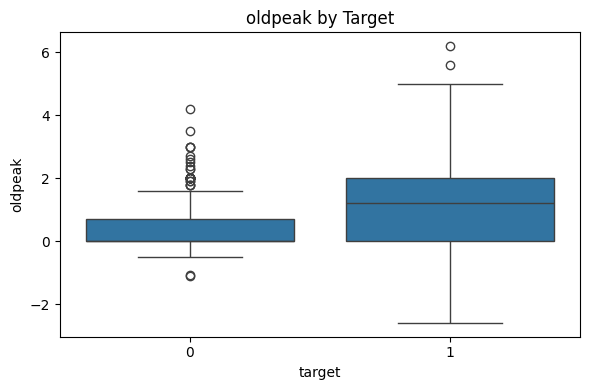

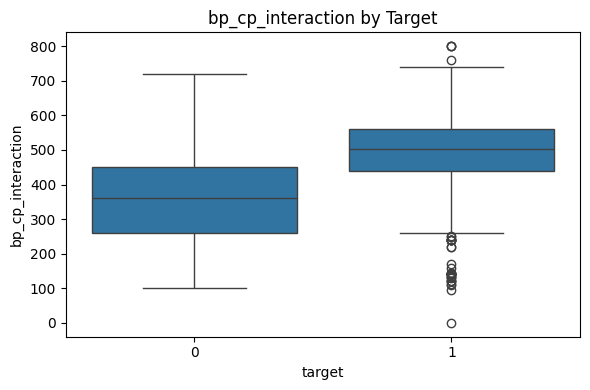

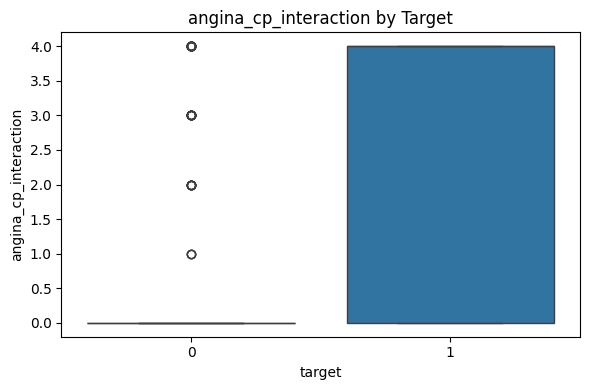

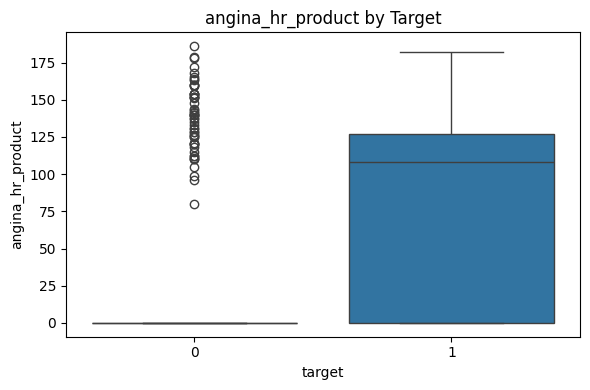

In [22]:
# Numerical vs Target
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} by Target')
    plt.tight_layout()
    plt.show()

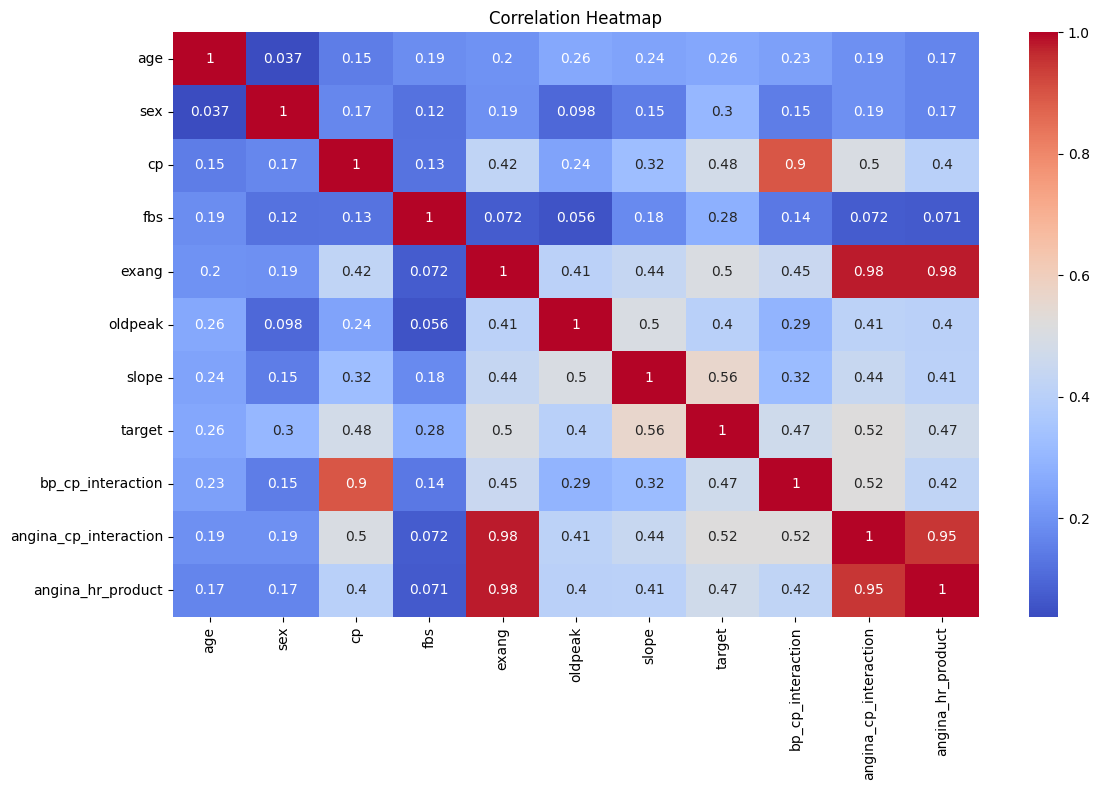

In [23]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [24]:
def replace_outliers_with_median(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    median = column.median()
    return column.apply(lambda x: median if x < lower or x > upper else x)


for col in numeric_cols:
    df[col] = replace_outliers_with_median(df[col])

print(df[numeric_cols].describe())

              age    oldpeak  bp_cp_interaction  angina_cp_interaction  \
count  947.000000  947.00000         947.000000             947.000000   
mean    53.662091    0.82167         428.269271               1.462513   
std      9.443381    0.95679         140.265854               1.860749   
min     28.000000   -2.00000          95.000000               0.000000   
25%     47.000000    0.00000         320.000000               0.000000   
50%     54.000000    0.50000         448.000000               0.000000   
75%     60.000000    1.50000         528.000000               4.000000   
max     77.000000    3.70000         800.000000               4.000000   

       angina_hr_product  
count         947.000000  
mean           49.255544  
std            62.591364  
min             0.000000  
25%             0.000000  
50%             0.000000  
75%           119.000000  
max           186.000000  


<ipython-input-25-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


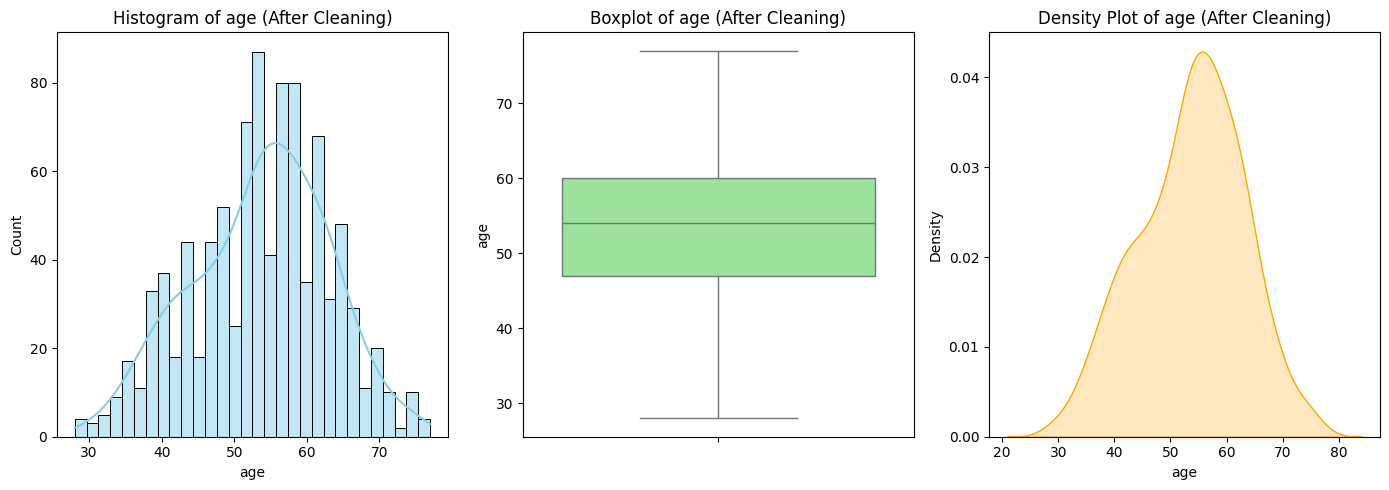

<ipython-input-25-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


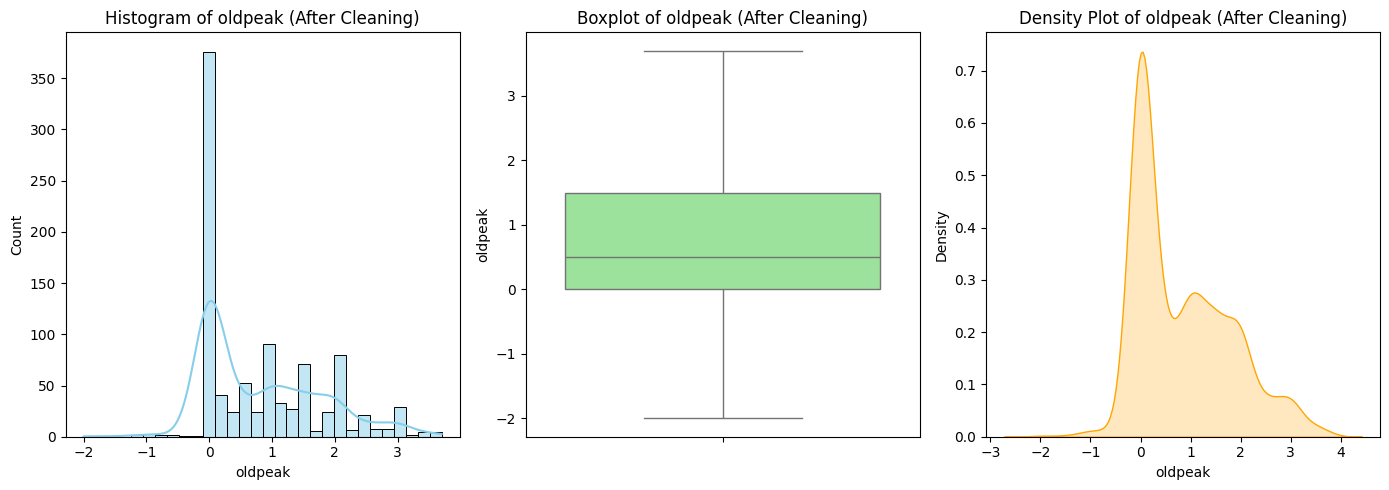

<ipython-input-25-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


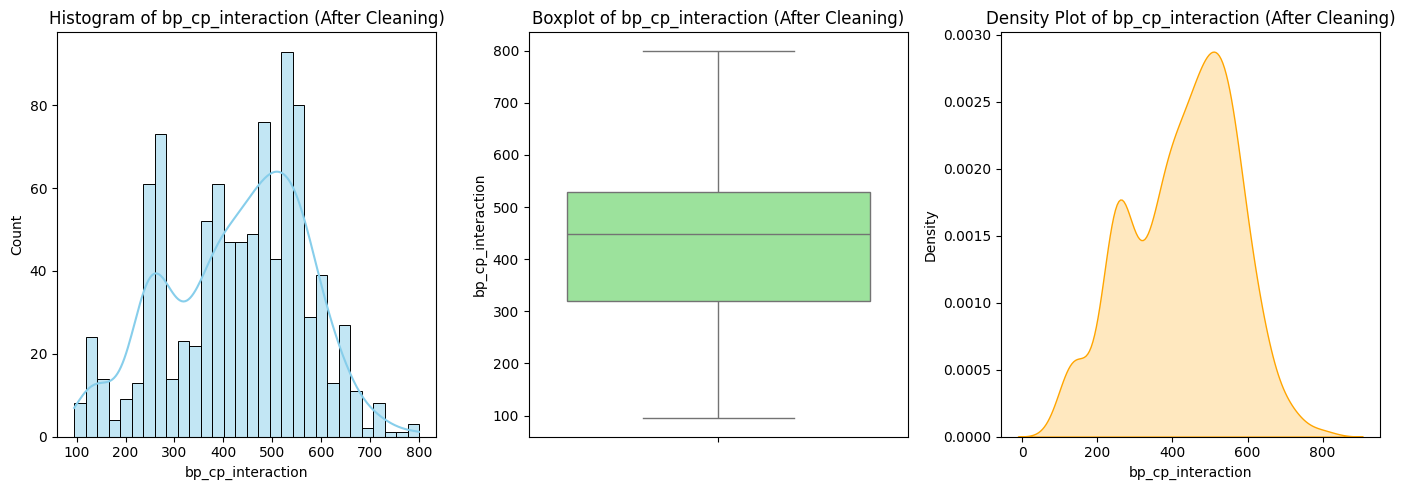

<ipython-input-25-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


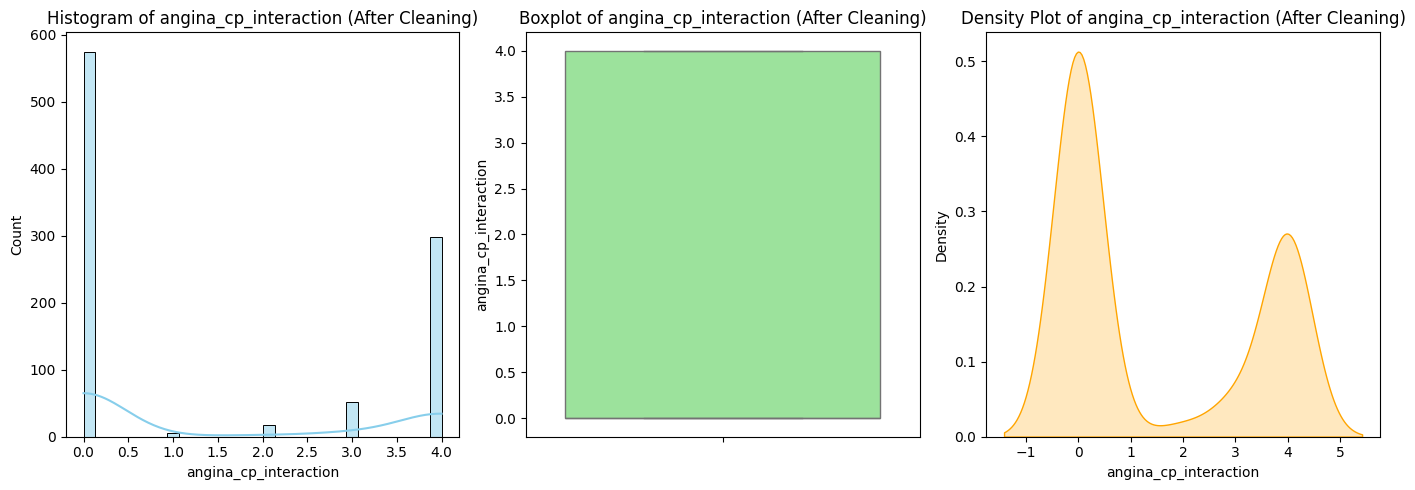

<ipython-input-25-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


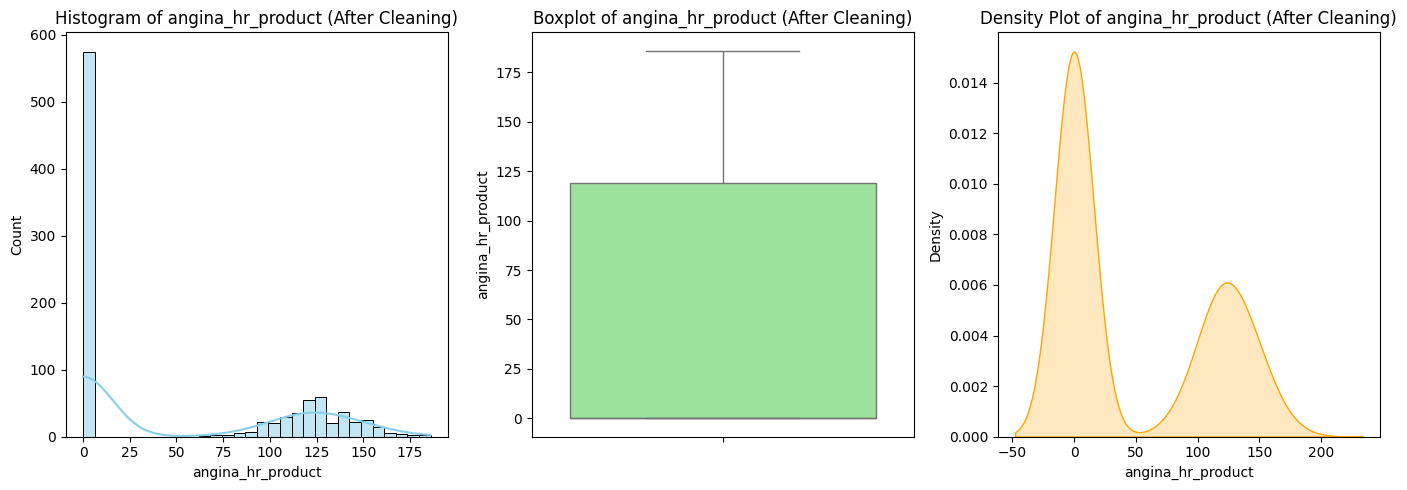

In [25]:
# after outlier replacement
for col in numeric_cols:
    plt.figure(figsize=(14, 5))

    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {col} (After Cleaning)')

    # Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col} (After Cleaning)')

    # KDE plot
    plt.subplot(1, 3, 3)
    sns.kdeplot(df[col], shade=True, color='orange')
    plt.title(f'Density Plot of {col} (After Cleaning)')

    plt.tight_layout()
    plt.show()

In [26]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Toqa Hassan 202201868


In [27]:
models = {
    'k-NN': KNeighborsClassifier(n_neighbors=5)}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'model': model,
        'report': classification_report(y_test, y_pred),
        'confusion': confusion_matrix(y_test, y_pred)
    }




# **k-Nearest Neighbors (k-NN)**
Prediction: 100% probability of No Disease



In [28]:
# LIME Explainability
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    mode='classification'
)

for model_name in models:
    print(f"\n--- LIME Explanation for {model_name} ---")
    model = results[model_name]['model']
    explanation = lime_explainer.explain_instance(
        data_row=X_test_scaled[0],
        predict_fn=model.predict_proba,
        num_features=3
    )
    explanation.show_in_notebook(show_table=True)





--- LIME Explanation for k-NN ---




# **k-Nearest Neighbors (k-NN)**
Top features:

slope (ST segment slope)

sex

fbs (fasting blood sugar)

Features like angina_hr_product and age had low influence.





--- Permutation Importance for k-NN ---


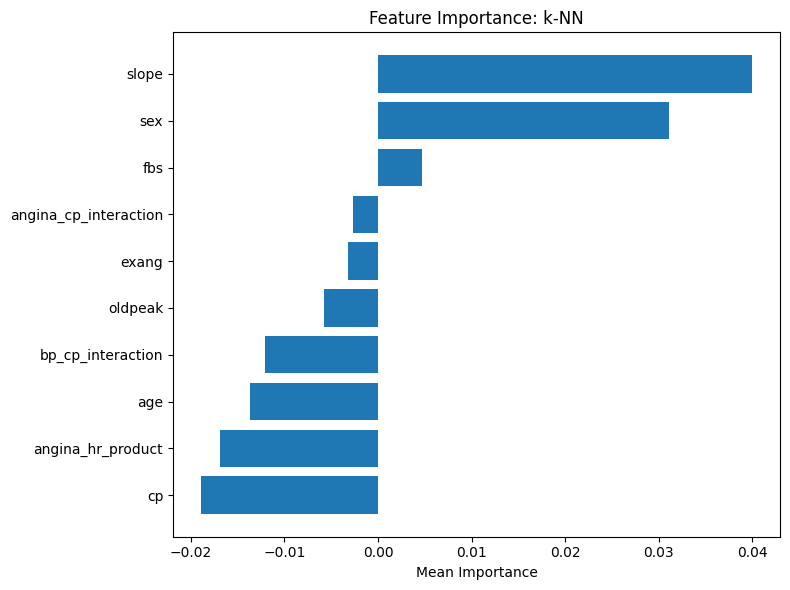

In [29]:
# Permutation Importance
for model_name in models:
    print(f"\n--- Permutation Importance for {model_name} ---")
    model = results[model_name]['model']
    perm = permutation_importance(model, X_test_scaled, y_test, n_repeats=10, random_state=42)
    sorted_idx = perm.importances_mean.argsort()
    plt.figure(figsize=(8, 6))
    plt.barh(np.array(X.columns)[sorted_idx], perm.importances_mean[sorted_idx])
    plt.title(f"Feature Importance: {model_name}")
    plt.xlabel("Mean Importance")
    plt.tight_layout()
    plt.show()



# **PDP**

# k-Nearest Neighbors (k-NN)
bp_cp_interaction: Generally increases risk but with variability.

angina_cp_interaction: Weak upward trend — less impactful.

angina_hr_product: Noisy and minimal effect — not very informative.





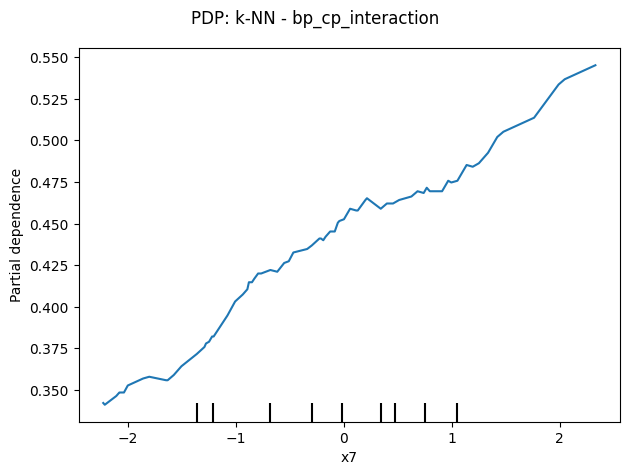

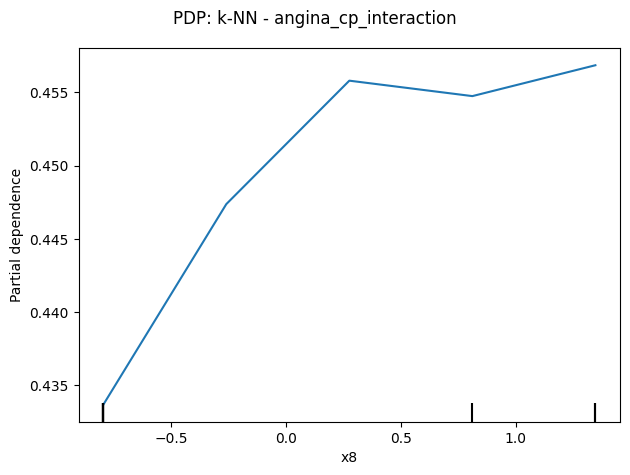

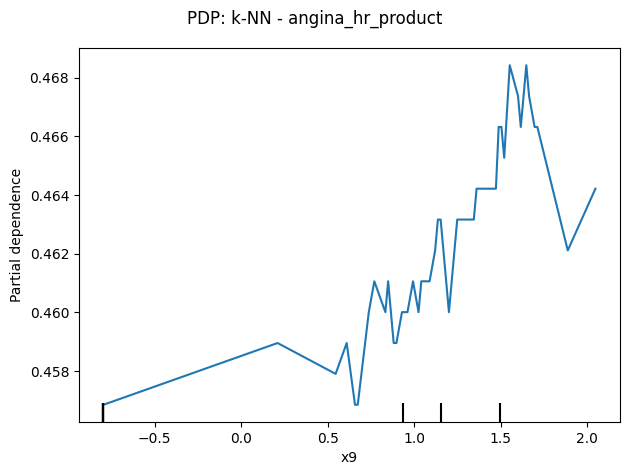

In [30]:
# PDP
important_features = ['bp_cp_interaction', 'angina_cp_interaction', 'angina_hr_product']

for model_name in models:
    model = results[model_name]['model']
    for feat in important_features:
        PartialDependenceDisplay.from_estimator(model, X_test_scaled, [X.columns.get_loc(feat)], kind='average')
        plt.suptitle(f"PDP: {model_name} - {feat}")
        plt.tight_layout()
        plt.show()



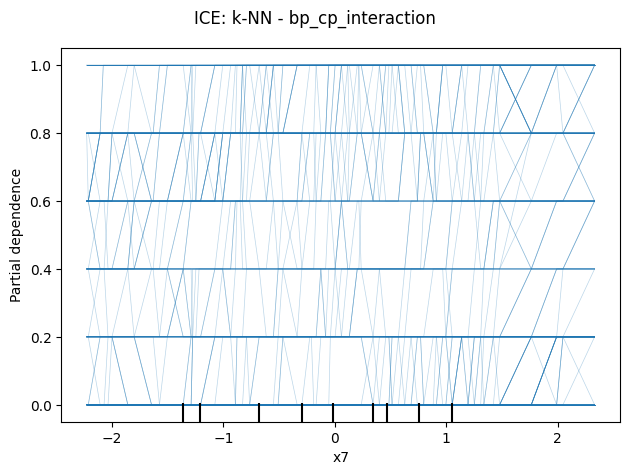

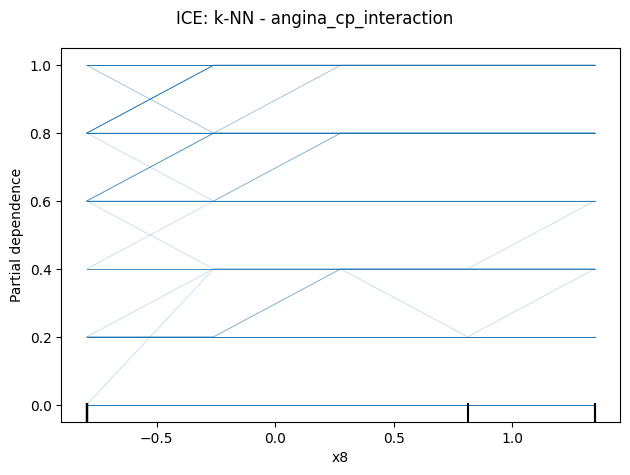

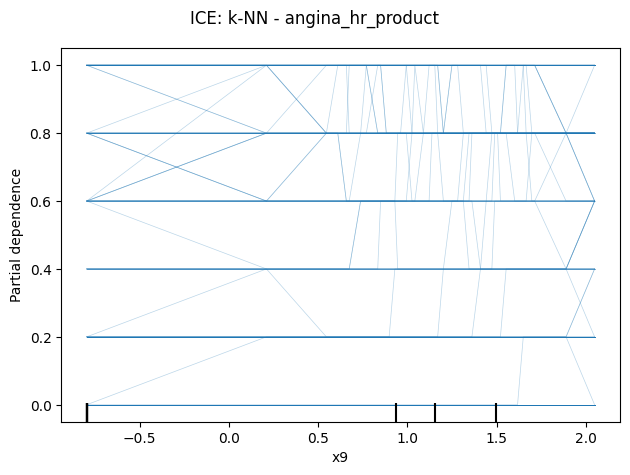

In [31]:
# ICE Plots
for model_name in models:
    model = results[model_name]['model']
    for f in important_features:
        PartialDependenceDisplay.from_estimator(model, X_test_scaled, [X.columns.get_loc(f)], kind='individual')
        plt.suptitle(f"ICE: {model_name} - {f}")
        plt.tight_layout()
        plt.show()